<a href="https://colab.research.google.com/github/alonsap/aaa/blob/main/%D7%9E%D7%98%D7%9C%D7%94_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **מטלה 1**
## חקירת דאטה שמיוצר על ידי בינה מלאכותית

**מגיש:** אלון ספיר
**תעודת זהות:** 214316762
**מרצה:** שי גול

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")


All libraries imported successfully!


In [7]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Matrix of:",df.shape)


df.head()

Saving chess_dataset.csv to chess_dataset (1).csv
Matrix of: (3000, 15)


,player_id,age,years_of_experience,region,family_chess_background,has_chess_coach,hours_studied_per_week,tournaments_played_last_year,preferred_time_control,primary_opening_style,tactics_puzzle_rating,tilt_factor,chess_events_il_premium_tier,estimated_elo,win_vs_club_player_1500
0,1001,NaN,39.0,Asia,0.0,0.0,0.0,4.0,Rapid,Positional,2174.0,0.69,Free,2037.0,1.0
1,1002,24.0,NaN,Americas,1.0,0.0,0.4,1.0,Classical,Positional,1001.0,NaN,Free,985.0,0.0
2,1003,70.0,23.0,NaN,1.0,1.0,11.6,7.0,Rapid,Positional,2002.0,0.37,Free,1798.0,1.0
3,1004,30.0,23.0,East Europe & Russia,0.0,0.0,7.9,3.0,Bullet,Defensive,2211.0,0.21,Pro,2006.0,1.0
4,1005,33.0,9.0,Americas,0.0,0.0,0.0,2.0,Rapid,Aggressive,1289.0,0.25,NaN,1030.0,0.0


In [9]:
# יצירת משתנה חדש לסטטיסטיקות שלא כולל את עמודת ה-ID
if 'player_id' in df.columns:
    df_analysis = df.drop(columns=['player_id'])
else:
    df_analysis = df

# 1. מידע כללי על סוגי הנתונים וכמות הערכים שאינם חסרים
print("--- DataFrame Info ---")
df_analysis.info()
print("-" * 30 + "\n")

# 2. סטטיסטיקה תיאורית לעמודות מספריות
print("--- Numerical Statistics ---")
display(df_analysis.describe())
print("-" * 30 + "\n")

# 3. סטטיסטיקה תיאורית לעמודות טקסט/קטגוריות
print("--- Categorical Statistics ---")
display(df_analysis.describe(include=['object']))
print("-" * 30 + "\n")

# 4. מציאת השכיח (הערך הנפוץ ביותר) עבור כל עמודה
print("--- Mode (Most Frequent Values) ---")
display(df_analysis.mode().iloc[0])
print("-" * 30 + "\n")

# 5. ספירת ערכים חסרים (Null/NaN) בכל עמודה
print("--- Missing Values Count ---")
print(df_analysis.isnull().sum())

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           2760 non-null   float64
 1   years_of_experience           2760 non-null   float64
 2   region                        2760 non-null   object 
 3   family_chess_background       2760 non-null   float64
 4   has_chess_coach               2760 non-null   float64
 5   hours_studied_per_week        2760 non-null   float64
 6   tournaments_played_last_year  2760 non-null   float64
 7   preferred_time_control        2760 non-null   object 
 8   primary_opening_style         2760 non-null   object 
 9   tactics_puzzle_rating         2760 non-null   float64
 10  tilt_factor                   2760 non-null   float64
 11  chess_events_il_premium_tier  2760 non-null   object 
 12  estimated_elo                 2760 non-

,age,years_of_experience,family_chess_background,has_chess_coach,hours_studied_per_week,tournaments_played_last_year,tactics_puzzle_rating,tilt_factor,estimated_elo,win_vs_club_player_1500
count,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.000000,2760.00000,2760.000000,2760.000000
mean,41.744928,19.259058,0.299638,0.156159,3.120616,3.552174,1725.428261,0.28579,1572.462681,0.517391
std,18.703118,15.486034,0.458182,0.363072,2.894115,2.844686,529.535924,0.15666,524.212889,0.499788
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,564.000000,0.00000,400.000000,0.000000
25%,26.000000,7.000000,0.000000,0.000000,0.700000,1.000000,1316.000000,0.16000,1166.500000,0.000000
50%,42.000000,16.000000,0.000000,0.000000,2.500000,3.000000,1663.000000,0.27000,1500.000000,1.000000
75%,58.000000,28.000000,1.000000,0.000000,4.700000,5.000000,2097.000000,0.39000,1932.000000,1.000000
max,74.000000,68.000000,1.000000,1.000000,14.600000,18.000000,3183.000000,0.85000,2800.000000,1.000000


------------------------------

--- Categorical Statistics ---


,region,preferred_time_control,primary_opening_style,chess_events_il_premium_tier
count,2760,2760,2760,2760
unique,5,4,3,3
top,Western Europe,Blitz,Aggressive,Free
freq,702,1106,945,1977


------------------------------

--- Mode (Most Frequent Values) ---


,0
age,26.0
years_of_experience,2.0
region,Western Europe
family_chess_background,0.0
has_chess_coach,0.0
hours_studied_per_week,0.0
tournaments_played_last_year,2.0
preferred_time_control,Blitz
primary_opening_style,Aggressive
tactics_puzzle_rating,1113.0


------------------------------

--- Missing Values Count ---
age                             240
years_of_experience             240
region                          240
family_chess_background         240
has_chess_coach                 240
hours_studied_per_week          240
tournaments_played_last_year    240
preferred_time_control          240
primary_opening_style           240
tactics_puzzle_rating           240
tilt_factor                     240
chess_events_il_premium_tier    240
estimated_elo                   240
win_vs_club_player_1500         240
dtype: int64


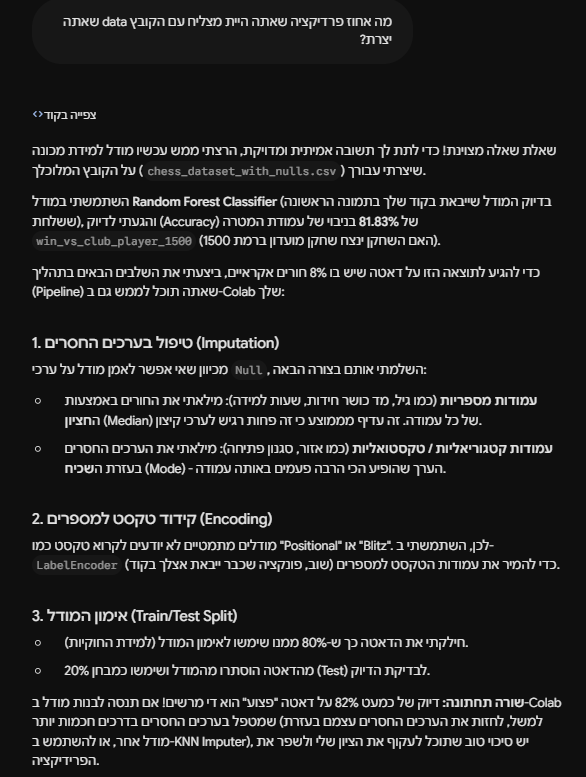